# Landslide4Sense: UNet / ResUNet / MUNet / ResMUNet

Exploratory notebook. For reproducible runs use `train.py`, `evaluate.py` and `scripts/run_experiments.sh`.

**Note on the numbers in the paper.** The original models ended in a sigmoid and the original evaluator applied a second one, so its `threshold=0.6` corresponded to a probability threshold of about 0.405 (logit(0.6)), and that threshold was not selected on validation data. Models now return logits, sigmoid is applied once, and the threshold is selected on the validation split. Outputs of the edited cells were cleared; re-run to regenerate them.


In [ ]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import jaccard_score, precision_score, recall_score, f1_score, cohen_kappa_score, accuracy_score

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
from data import compute_mean_std, LandslideDataset, train_val_split

In [ ]:
# mean, std = compute_mean_std(sorted(glob.glob('datasets/images/train/*.h5')))
from data import MEAN as mean, STD as std

Import Dataset

In [ ]:
train_dataset = LandslideDataset(
        image_dir='datasets/images/train',
        mask_dir='datasets/annotations/train',
        mean=mean,
        std=std
    )

train_dataset, val_dataset = train_val_split(train_dataset, val_fraction=0.2, seed=42)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

In [44]:
image, mask = train_dataset[0]
print("Image shape:", image.shape)

Image shape: torch.Size([6, 128, 128])


In [45]:
def show_sample(data_loader,num_rows=5):
    data_iter = iter(data_loader)
    batch_size = num_rows
    images, masks = next(data_iter)
    images = images[:batch_size].to('cpu')
    masks = masks[:batch_size].to('cpu')

    fig, axes = plt.subplots(num_rows,5,figsize=(5*4,num_rows*4))
    for i in range(batch_size):
        img = images[i].cpu()
        mask = masks[i].cpu()

        img_np = img.permute(1,2,0).numpy()
        if mask.ndim==3 and mask.shape[0] == 1:
            mask_np = mask.squeeze(0).numpy()
        else:
            mask_np = mask.numpy()
        # also denormalize these
        rgb = img_np[:,:,:3] * std[:3] + mean[:3]
        ndvi = img_np[:,:,3] * std[3] + mean[3]
        slope = img_np[:,:,4] * std[4] + mean[4]
        elevation = img_np[:,:,5] * std[5] + mean[5]
        axes[i,0].imshow(rgb)
        axes[i,0].axis('off')
        axes[i,0].set_title('RGB')

        axes[i,1].imshow(ndvi)
        axes[i,1].axis('off')
        axes[i,1].set_title('NDVI')

        axes[i,2].imshow(slope)
        axes[i,2].axis('off')
        axes[i,2].set_title('Slope')

        axes[i,3].imshow(elevation)
        axes[i,3].axis('off')
        axes[i,3].set_title('Elevation')

        axes[i,4].imshow(mask_np)
        axes[i,4].axis('off')
        axes[i,4].set_title('Mask')
    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8603398842294453..4.8610325787849575].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.38861304391992324..2.230593996362872].


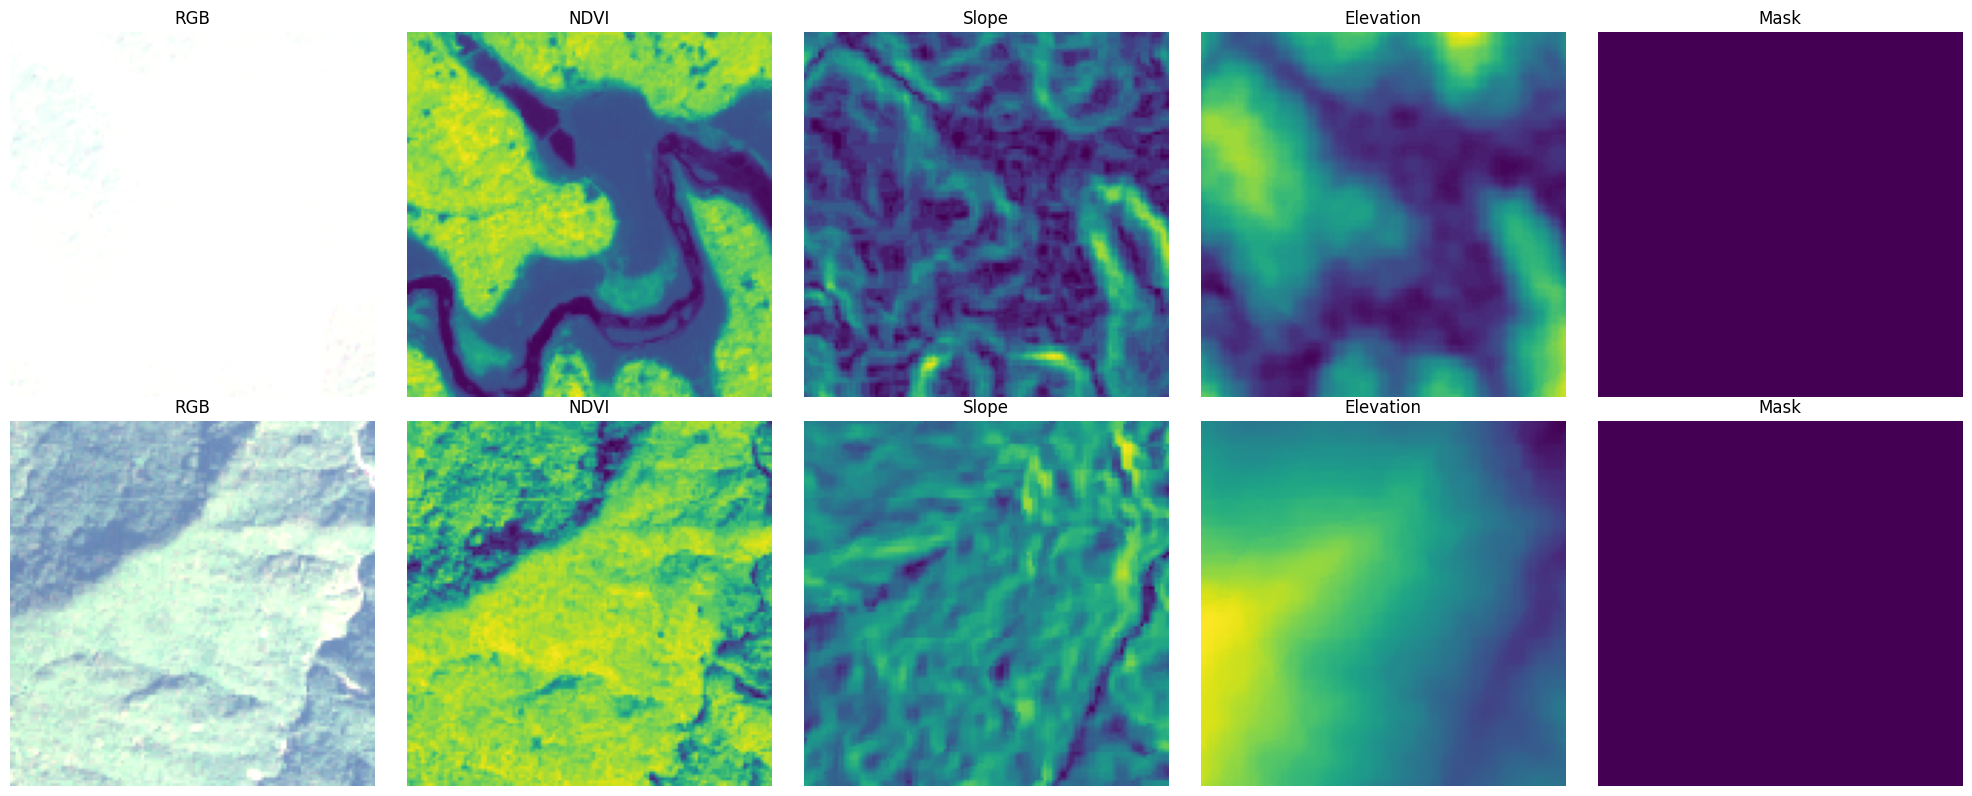

In [46]:
show_sample(train_loader,2)

Import model

In [ ]:
from models import UNET, RESUNET, MUNET, ResMUNET  # all return logits

In [ ]:
def compute_metrics(y_pred, y_true):
    y_pred = (torch.sigmoid(y_pred) >= 0.5).cpu().numpy().astype(np.uint8).flatten()
    y_true = y_true.cpu().numpy().astype(np.uint8).flatten()
    return {
        'dice': f1_score(y_true, y_pred),
        'iou': jaccard_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
    }

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20, early_stop_patience=4):
    best_val_loss = float('inf')
    early_stop_counter = 0
    history = {'loss':[],'dice':[],'iou':[],'precision':[],'recall':[],'accuracy':[],'f1':[]}

    train_losses = []
    val_losses = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0.0
        metrics = {'dice':0,'iou':0,'precision':0,'recall':0,'accuracy':0,'f1':0}

        for batch_idx, (images, masks) in enumerate(train_loader):
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            batch_metrics = compute_metrics(outputs, masks)
            for k in metrics:
                metrics[k] += batch_metrics[k]

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        history['loss'].append(avg_train_loss)
        for k in metrics:
            history[k].append(metrics[k] / len(train_loader))

        # Validation phase
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Update learning rate scheduler
        scheduler.step(avg_val_loss)

        # Print and check for early stoppinga
        print(f'Epoch [{epoch}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}, Learning Rate: {scheduler.get_last_lr()[0]}')

        if avg_val_loss < best_val_loss:
            os.makedirs('runs', exist_ok=True)
            torch.save(model.state_dict(), f'runs/{model}_best_model.pth')  # never overwrite the released models/*.pth
            best_val_loss = avg_val_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= early_stop_patience:
            print(f'Early stopping after {early_stop_patience} epochs without improvement.')
            break

    return train_losses, val_losses, history

In [ ]:
LEARNING_RATE = 0.001
LR_FACTOR = 0.5
LR_PATIENCE = 2
EARLY_STOP_PATIENCE = 7
NUM_EPOCHS = 20
device = "cuda" if torch.cuda.is_available() else "cpu"

from losses import dice_loss, bce_dice_loss  # both take logits


In [53]:
# model  = UNET().to(device)

# criterion = bce_dice_loss
# optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE)

In [54]:
# train_losses, val_losses, history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=30, early_stop_patience=5)

In [55]:
# model  = RESUNET().to(device)

# criterion = bce_dice_loss
# optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE)

In [56]:
# train_losses, val_losses, history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=30, early_stop_patience=5)

In [57]:
# model  = MUNET().to(device)

# criterion = bce_dice_loss
# optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE)

In [58]:
# train_losses, val_losses, history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=30, early_stop_patience=5)

In [59]:
# model  = ResMUNET().to(device)

# criterion = bce_dice_loss
# optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE)

In [60]:
# train_losses, val_losses, history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=30, early_stop_patience=5)

In [61]:
# # plotting only train metric and loss
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# plt.plot(history['loss'], label='Loss')
# plt.title('Loss over Epochs')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.grid(True)

# plt.subplot(1, 2, 2)
# plt.plot(history['dice'], label='Dice')
# plt.plot(history['iou'], label='IoU')
# plt.plot(history['precision'], label='Precision')
# plt.plot(history['recall'], label='Recall')
# plt.plot(history['accuracy'], label='Accuracy')
# plt.plot(history['f1'], label='F1')
# plt.title('Metrics over Epochs')
# plt.xlabel('Epoch')
# plt.ylabel('Score')
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
# plt.savefig('training_metrics.png')
# plt.show()

In [62]:
def save_mask_to_h5(mask_array, save_path, dataset_name='mask'):
    with h5py.File(save_path, 'w') as f:
        f.create_dataset(dataset_name, data=mask_array, compression='gzip')
    print(f"Mask saved to {save_path}")

In [ ]:
# Function to plot examples with predicted and true masks
def plot_examples(model, dataset, num_examples=5):
    model.eval()

    for i in range(num_examples):
        image, mask = dataset[i]

        with torch.no_grad():
            output = torch.sigmoid(model(image.unsqueeze(0).to(device))).cpu()

        pred_mask = output.squeeze(0)

        # Plot the images and masks  
        plt.figure(figsize=(12, 4))
        image = (image[:3].permute(1,2,0).numpy()) * std[:3] + mean[:3]

        plt.subplot(1, 3, 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title('Image')

        plt.subplot(1, 3, 2)
        plt.imshow(mask.permute(1,2,0))
        plt.axis("off")
        plt.title('True Mask')

        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask.permute(1,2,0))
        plt.axis("off")
        plt.title('Predicted Mask')

        plt.tight_layout()

        true_mask_np = mask.squeeze().numpy()  # or adjust if mask shape different
        # Save true mask
        # save_mask_to_h5(true_mask_np, f'true_mask_{i}.h5')
        

        pred_mask_np = pred_mask.squeeze().numpy()
        # Save predicted mask
        save_mask_to_h5(pred_mask_np, f'pred_mask_{i}.h5')

        plt.show()


In [ ]:
from evaluator import evaluate, select_threshold
# The decision threshold is chosen on the validation split, never on test.

eval_dataset = LandslideDataset(
    image_dir='datasets/images/test',
    mask_dir='datasets/annotations/test',
    mean=mean,
    std=std
)
eval_dataloader = DataLoader(eval_dataset, batch_size=16, shuffle=False)

Evaluate the UNet

In [ ]:
model_path = 'models/UNet_best_model.pth'
model = UNET()
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.to(device)
model.eval()

threshold, _ = select_threshold(model, val_loader, device)
metrics = evaluate(model, eval_dataloader, device, threshold)

Evaluate the ResUNet model

In [ ]:
model_path = 'models/ResUNet_best_model.pth'
model = RESUNET()
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.to(device)
model.eval()

threshold, _ = select_threshold(model, val_loader, device)
metrics = evaluate(model, eval_dataloader, device, threshold)

Evaluate the MUNet model

In [ ]:
model_path = 'models/MUNet_best_model.pth'
model = MUNET()
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.to(device)
model.eval()

threshold, _ = select_threshold(model, val_loader, device)
metrics = evaluate(model, eval_dataloader, device, threshold)

Evaluate the ResMUNet model

In [ ]:
model_path = 'models/ResMUNet_best_model.pth'
model = ResMUNET()
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.to(device)
model.eval()

threshold, _ = select_threshold(model, val_loader, device)
metrics = evaluate(model, eval_dataloader, device, threshold)

Qualitative examples from the **test** split (uses the last model loaded above)

In [ ]:
plot_examples(model, eval_dataset, num_examples=3)